# Near fields of an accelerated particle

Assume an electron moving on a circular trajectory with radius $R_t$ crossing the origin at time zero.<br>
Compute the fields around the particle using the Liennard-Wiechert formula including proper retardation effects.<br>
All computations are done in the laboratory coordinate system.

$ \vec{E}(\vec{x},t) =
\frac{Q}{4 \pi \varepsilon_{0}} \;
\left[ \frac{\vec{n}-\vec{\beta}}{\gamma^2 \, (1-\vec{\beta}\cdot\vec{n})^3 \, R^2} \right]_{ret} +
\frac{Q}{4 \pi \varepsilon_{0}} \;
\left[ \frac{\vec{n} \times \{ (\vec{n}-\vec{\beta}) \times \dot{\vec{\beta}} \} }{(1-\vec{\beta}\cdot\vec{n})^3 \, R c} \right]_{ret}
$

In [1]:
from math import *
import numpy as np
import scipy.constants as sc
import matplotlib.pyplot as plt
from scipy.optimize import root
from numpy.linalg import norm as vabs

In [2]:
mec2 = sc.m_e*sc.c**2/sc.e
γ = 20.0e6 / mec2
β = sqrt(1.0-1.0/γ**2)
print(β, γ)

0.9996735468055344 39.13902367147747


In [3]:
# trajectory
Rt = 0.3
α = lambda t: β*sc.c*t / Rt
α_t = β*sc.c / Rt

# time-dependent particle position, velocity and acceleration
X = lambda t: Rt * np.array([cos(α(t))-1.0,sin(α(t)),0.0])
B = lambda t: β * np.array([-sin(α(t)),cos(α(t)),0.0])
B_t = lambda t: β * α_t * np.array([-cos(α(t)),-sin(α(t)),0.0])

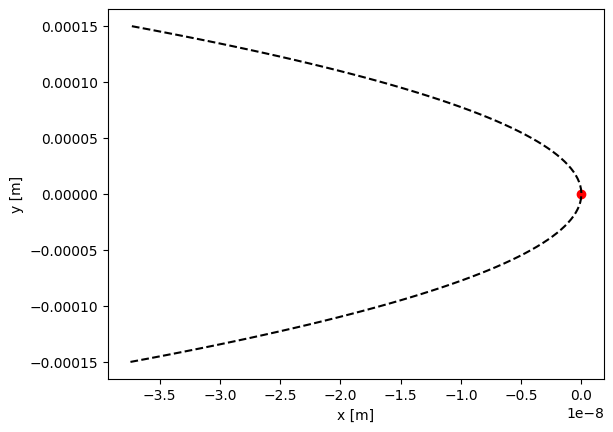

In [4]:
t_plot = np.linspace(-0.5e-12, 0.5e-12, 100)
X_traj = np.stack([X(t) for t in t_plot])

plt.plot(X_traj[:,0],X_traj[:,1],'k--')
plt.scatter([0],[0],color='r')
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.show()

For a give observation point $P_{obs}$ solve the retardation condition for observation at time zero:

$|X(t_{src})-P_{obs}| + c t_{src} = 0$

The signal observed at $P_{obs}$ originates from the particle at time $t_{src}$.

In [5]:
R = lambda t, P: vabs(X(t) - P)
def t_retardation(P):
    sol = root(lambda t_src: R(t_src, P) + sc.c*t_src, x0=[0.0])
    return sol.x[0]

In [6]:
P = np.array([1e-5, 0.0, 0.0])
t_ret = t_retardation(P)
print(f't_ret = {1e12*t_ret} ps')
print(f'X_src = {X(t_ret)} m')
print(f'R     = {R(t_ret,P)} m')

t_ret = -1.3400174568948584 ps
X_src = [-2.68798848e-07 -4.01595862e-04  0.00000000e+00] m
R     = 0.00040172712716541866 m


### visualize the retardation

In [7]:
Nx = 51
Ny = 51
dx = np.array([1.0e-4,0.0,0.0])
dy = np.array([0.0,0.5e-5,0.0])
O = -0.5*(Nx-1)*dx -0.5*(Ny-1)*dy
i, j = np.meshgrid(np.arange(Nx), np.arange(Ny), indexing='ij')
grid = i[..., np.newaxis] * dx + j[..., np.newaxis] * dy + O
print(grid.shape)

(51, 51, 3)


In [8]:
x_grid = grid[:,:,0]
y_grid = grid[:,:,1]
t_grid = np.apply_along_axis(t_retardation, axis=2, arr=grid)

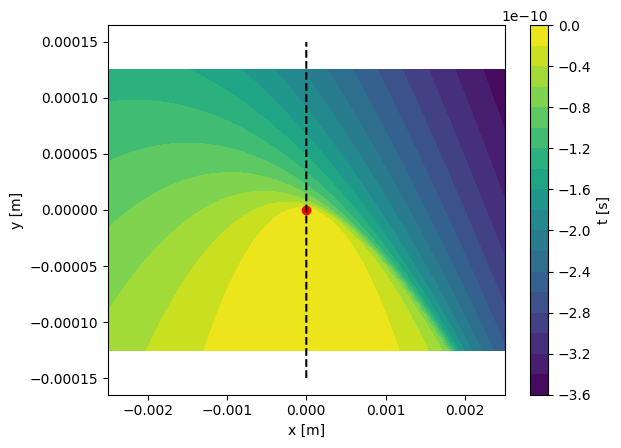

In [9]:
plt.contourf(x_grid,y_grid,t_grid,levels=20)
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.colorbar(label="t [s]")
plt.plot(X_traj[:,0],X_traj[:,1],'k--')
plt.scatter([0],[0],color='r')
plt.show()

In [10]:
def R_retardation(P):
    t_src = t_retardation(P)
    return vabs(X(t_src)-P)
R_grid = np.apply_along_axis(R_retardation, axis=2, arr=grid)

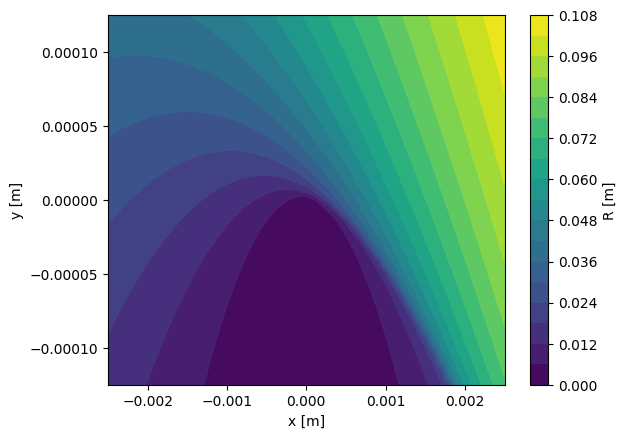

In [11]:
plt.contourf(x_grid,y_grid,R_grid,levels=20)
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.colorbar(label="R [m]")
plt.show()

### visualize Liennard-Wiechert fields

In [12]:
def E_lw(P):
    t_src = t_retardation(P)
    X_src = X(t_src)
    R_src = vabs(X_src-P)
    B_src = B(t_src)
    # print(B_src)
    Bp_src = B_t(t_src)
    n = P - X_src
    n /= vabs(n)
    # print(n)
    # scaling assumes 1nC of charge
    Q = 1e-9
    scale = Q / (4*np.pi*sc.epsilon_0)
    bnc = (1.0-np.dot(n,B_src))**3
    # velocity term
    E_v = scale * (n-B_src) / ( γ**2 * bnc * R_src**2 )
    # acceleration term
    E_a = scale * (np.cross(n,np.cross(n-B_src,Bp_src))) / ( bnc * R_src *sc.c )
    return E_v + E_a

In [13]:
P = np.array([1e-5, 0.0, 0.0])
E_lw(P)

array([ 3.70919139e+12, -1.73056670e+08,  0.00000000e+00])

In [14]:
Nx = 100
Ny = 100
dx = np.array([0.5e-4,0.0,0.0])
dy = np.array([0.0,0.25e-5,0.0])
O = -0.5*(Nx-1)*dx -0.5*(Ny-1)*dy
i, j = np.meshgrid(np.arange(Nx), np.arange(Ny), indexing='ij')
grid = i[..., np.newaxis] * dx + j[..., np.newaxis] * dy + O
print(grid.shape)

(100, 100, 3)


In [15]:
E_grid = np.apply_along_axis(E_lw, axis=2, arr=grid)
E_grid.shape

(100, 100, 3)

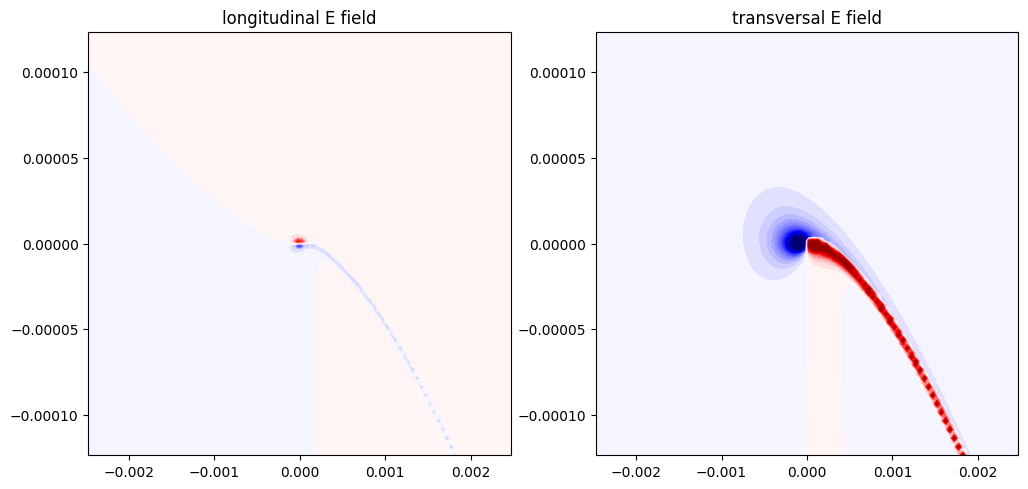

In [16]:
x_grid = grid[:,:,0]
y_grid = grid[:,:,1]
Ex = E_grid[:,:,0]
Ey = E_grid[:,:,1]

elevels = np.linspace(-0.5e10, 0.5e10, num=51)*1.1
E_trans = np.clip(Ex, -0.5e10, 0.5e10)
E_long = np.clip(Ey, -0.5e10, 0.5e10)

fig, (ax1, ax2) = plt.subplots(nrows=1,ncols=2,figsize=(12,5.5))
ax1.contourf(x_grid,y_grid,E_long,elevels,cmap='seismic')
ax1.set_title("longitudinal E field")
ax2.contourf(x_grid,y_grid,E_trans,elevels,cmap='seismic')
ax2.set_title("transversal E field")
plt.show()

### search for the quantisation effect

In [17]:
def bnc(P):
    t_src = t_retardation(P)
    X_src = X(t_src)
    R_src = vabs(X_src-P)
    B_src = B(t_src)
    # print(B_src)
    Bp_src = B_t(t_src)
    n = P - X_src
    n /= vabs(n)
    # print(n)
    # scaling assumes 1nC of charge
    Q = 1e-9
    scale = Q / (4*np.pi*sc.epsilon_0)
    # velocity term
    bnc = (1.0-np.dot(n,B_src))**3
    return 1.0/bnc

In [18]:
bnc_grid = np.apply_along_axis(bnc, axis=2, arr=grid)
bnc_grid.shape

(100, 100)

In [19]:
print(np.min(bnc_grid), np.max(bnc_grid))

0.14097077001253655 28739069653.229797


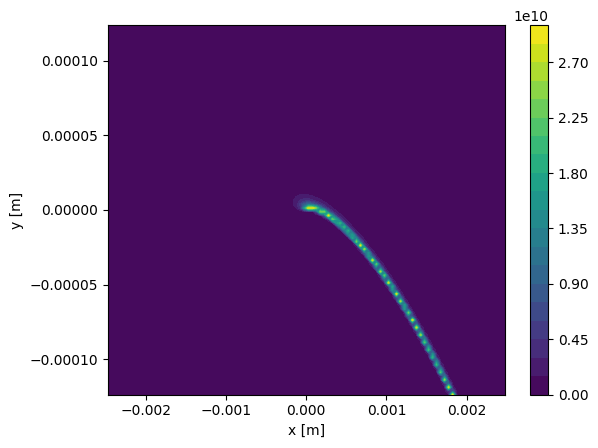

In [20]:
bnc_plot = np.clip(bnc_grid, 0.0, 1e12)

plt.contourf(x_grid,y_grid,bnc_plot,levels=20)
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.colorbar()
plt.show()

In [21]:
print(f'The 1/(1-n.β)³ term can reach {1/(1.0-β)**3:.2g} in case of co-linearity')
print(f'the magnitude of n-β is {1.0-β:.2g} in that case.')

The 1/(1-n.β)³ term can reach 2.9e+10 in case of co-linearity
the magnitude of n-β is 0.00033 in that case.


## We need to average the $ \frac{\vec{n}-\vec{\beta}}{(1-\vec{\beta}\cdot\vec{n})^3} $ term over one grid cell.

In [66]:
β_test = β * np.array([1.0, 0.0, 0.0])
def nb_func(δ):
    n_test = np.array([np.cos(δ), np.sin(δ), 0.0])
    return (n_test-β_test) / (1.0-np.dot(n_test,β_test))**3

In [67]:
print(nb_func(0))
print(nb_func(1e-3))
print(nb_func(1e-2))

[9383355.15846687       0.               0.        ]
[ 9326080.01938281 28611710.58358581        0.        ]
[5.18259464e+06 1.87463938e+08 0.00000000e+00]


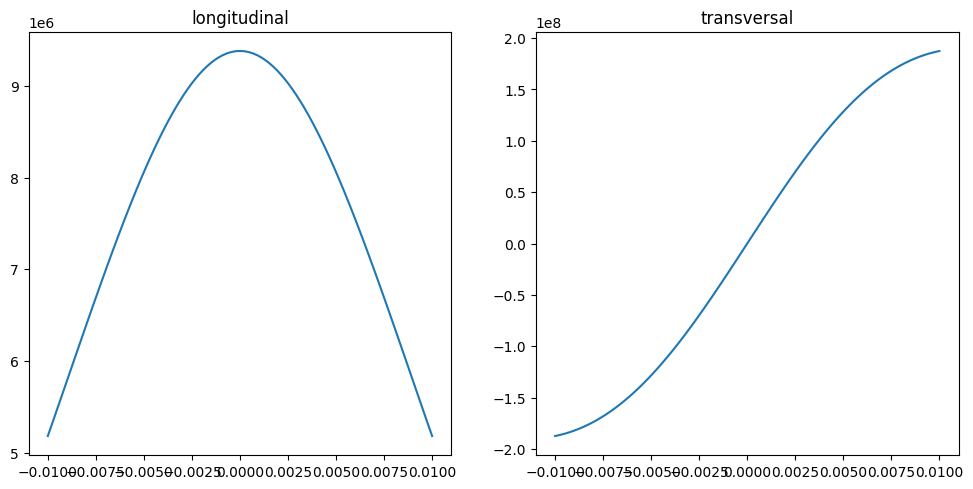

In [68]:
δ_plot = np.linspace(-1.0e-2, 1.0e-2, 100)
nbf_plot = np.stack([nb_func(δ) for δ in δ_plot])

fig, (ax1, ax2) = plt.subplots(nrows=1,ncols=2,figsize=(12,5.5))
ax1.plot(δ_plot,nbf_plot[:,0])
ax1.set_title("longitudinal")
ax2.plot(δ_plot,nbf_plot[:,1])
ax2.set_title("transversal")
plt.show()

grid: (200, 500)
grid_3D: (500, 200, 3)
E_grid: (500, 200, 3)
Ex: (500, 200)


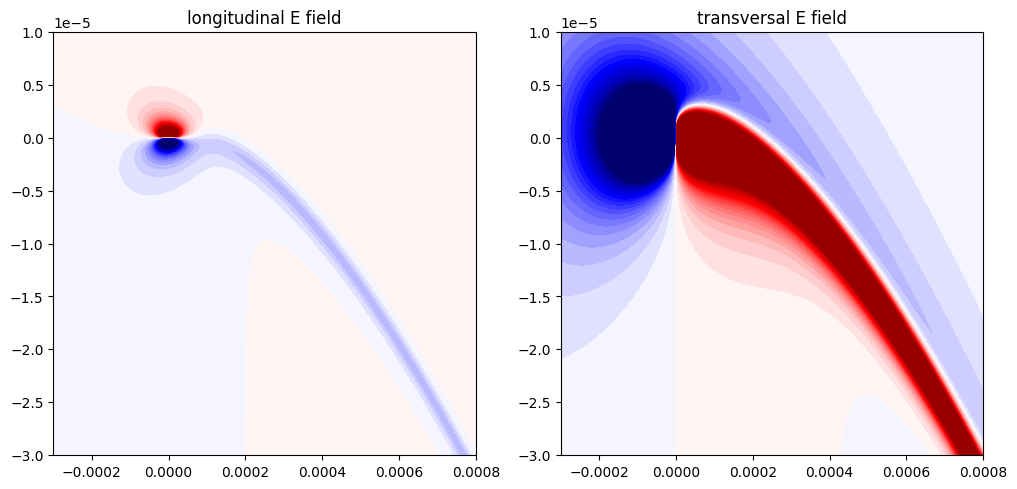

In [69]:
xp = np.linspace(-0.3e-3, 0.8e-3, 500)
yp = np.linspace(-3.0e-5, 1.0e-5, 200)
x_grid, y_grid = np.meshgrid(xp, yp)
print(f'grid: {x_grid.shape}')
z_grid = np.zeros_like(x_grid)
grid_3D = np.array([x_grid, y_grid, z_grid]).transpose()
print(f'grid_3D: {grid_3D.shape}')

E_grid = np.apply_along_axis(E_lw, axis=2, arr=grid_3D)
print(f'E_grid: {E_grid.shape}')
Ex = E_grid[:,:,0]
Ey = E_grid[:,:,1]
print(f'Ex: {Ex.shape}')

elevels = np.linspace(-0.5e10, 0.5e10, num=51)*1.1
E_trans = np.clip(Ex, -0.5e10, 0.5e10)
E_long = np.clip(Ey, -0.5e10, 0.5e10)

fig, (ax1, ax2) = plt.subplots(nrows=1,ncols=2,figsize=(12,5.5))
ax1.contourf(x_grid.transpose(),y_grid.transpose(),E_long,elevels,cmap='seismic')
ax1.set_title("longitudinal E field")
ax2.contourf(x_grid.transpose(),y_grid.transpose(),E_trans,elevels,cmap='seismic')
ax2.set_title("transversal E field")
plt.show()

## Visualize energy-dependency

In [22]:
xp = np.linspace(-0.5e-3, 1.0e-3, 500)
yp = np.linspace(-4.0e-5, 2.0e-5, 200)
x_grid, y_grid = np.meshgrid(xp, yp)
print(f'grid: {x_grid.shape}')
z_grid = np.zeros_like(x_grid)
grid_3D = np.array([x_grid, y_grid, z_grid]).transpose()
print(f'grid_3D: {grid_3D.shape}')

grid: (200, 500)
grid_3D: (500, 200, 3)


0.9986935469557356 19.569511835738734
E_grid: (500, 200, 3)
Ex: (500, 200)


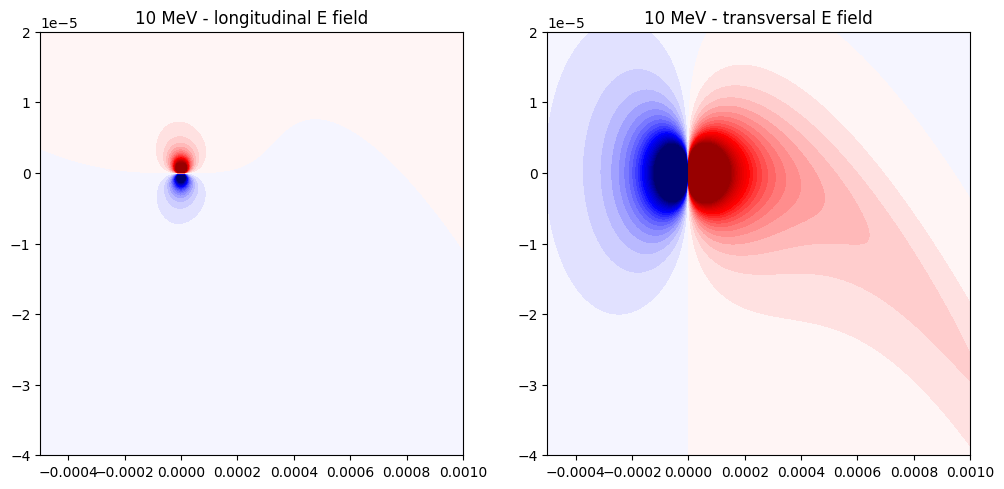

In [49]:
γ = 10.0e6 / mec2
β = sqrt(1.0-1.0/γ**2)
print(β, γ)

E_grid = np.apply_along_axis(E_lw, axis=2, arr=grid_3D)
print(f'E_grid: {E_grid.shape}')
Ex = E_grid[:,:,0]
Ey = E_grid[:,:,1]
print(f'Ex: {Ex.shape}')

elevels = np.linspace(-1.0e10, 1.0e10, num=51)*1.1
E_trans = np.clip(Ex, -1.0e10, 1.0e10)
E_long = np.clip(Ey, -1.0e10, 1.0e10)

fig, (ax1, ax2) = plt.subplots(nrows=1,ncols=2,figsize=(12,5.5))
ax1.contourf(x_grid.transpose(),y_grid.transpose(),E_long,elevels,cmap='seismic')
ax1.set_title("10 MeV - longitudinal E field")
ax2.contourf(x_grid.transpose(),y_grid.transpose(),E_trans,elevels,cmap='seismic')
ax2.set_title("10 MeV - transversal E field")
plt.show()

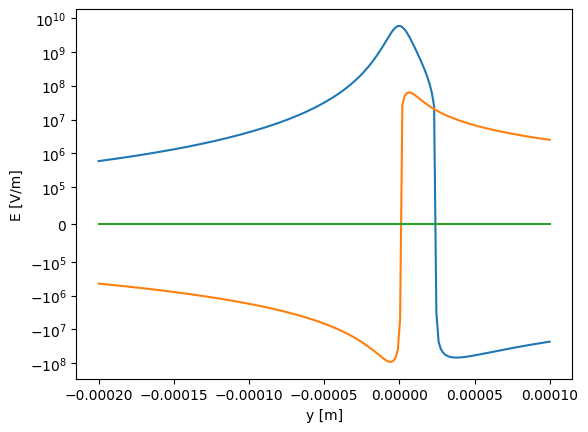

In [52]:
y_range = np.linspace(-20.0e-5, 10.0e-5,200)
P = np.stack([np.ones_like(y_range)*0.0002, y_range, np.zeros_like(y_range)]).transpose()
E_plot = np.apply_along_axis(E_lw, axis=1, arr=P)

fig, ax = plt.subplots()
ax.plot(y_range, E_plot)
ax.set_yscale('symlog', linthresh=1e5, linscale=1.0, base=10)
# plt.semilogy()
plt.xlabel('y [m]')
plt.ylabel('E [V/m]')
plt.show()

0.9996735468055344 39.13902367147747
E_grid: (500, 200, 3)
Ex: (500, 200)


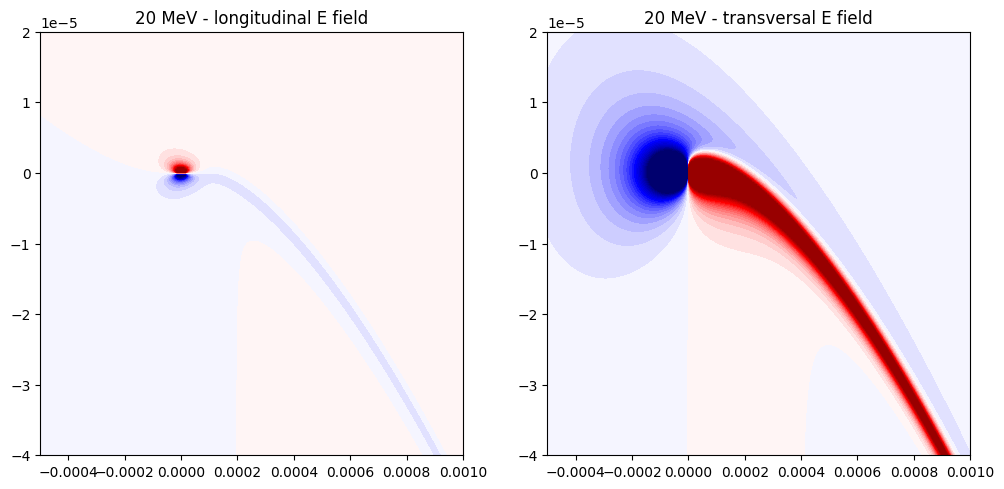

In [37]:
γ = 20.0e6 / mec2
β = sqrt(1.0-1.0/γ**2)
print(β, γ)

E_grid = np.apply_along_axis(E_lw, axis=2, arr=grid_3D)
print(f'E_grid: {E_grid.shape}')
Ex = E_grid[:,:,0]
Ey = E_grid[:,:,1]
print(f'Ex: {Ex.shape}')

elevels = np.linspace(-1.0e10, 1.0e10, num=51)*1.1
E_trans = np.clip(Ex, -1.0e10, 1.0e10)
E_long = np.clip(Ey, -1.0e10, 1.0e10)

fig, (ax1, ax2) = plt.subplots(nrows=1,ncols=2,figsize=(12,5.5))
ax1.contourf(x_grid.transpose(),y_grid.transpose(),E_long,elevels,cmap='seismic')
ax1.set_title("20 MeV - longitudinal E field")
ax2.contourf(x_grid.transpose(),y_grid.transpose(),E_trans,elevels,cmap='seismic')
ax2.set_title("20 MeV - transversal E field")
plt.show()

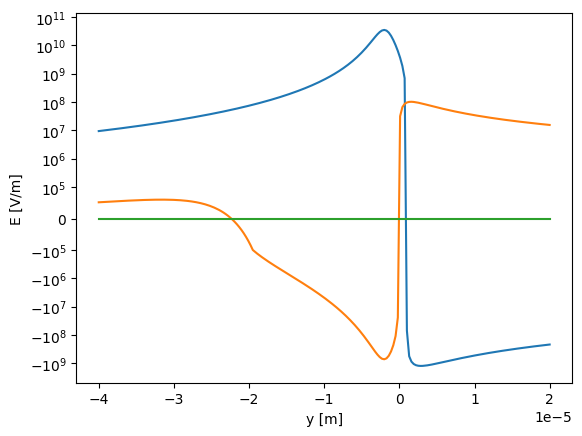

In [44]:
y_range = np.linspace(-4.0e-5, 2.0e-5,200)
P = np.stack([np.ones_like(y_range)*0.0002, y_range, np.zeros_like(y_range)]).transpose()
E_plot = np.apply_along_axis(E_lw, axis=1, arr=P)

fig, ax = plt.subplots()
ax.plot(y_range, E_plot)
ax.set_yscale('symlog', linthresh=1e5, linscale=1.0, base=10)
# plt.semilogy()
plt.xlabel('y [m]')
plt.ylabel('E [V/m]')
plt.show()

0.9998549228502563 58.7085355072162
E_grid: (500, 200, 3)
Ex: (500, 200)


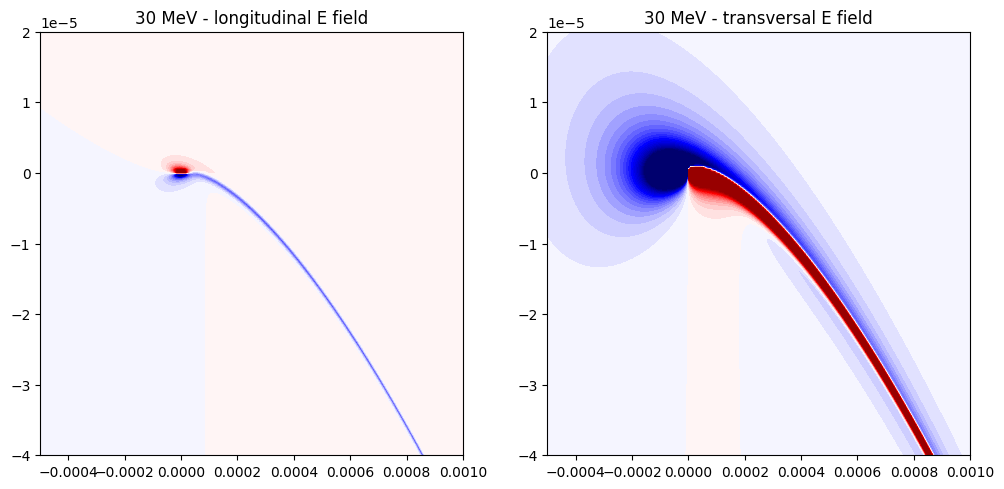

In [47]:
γ = 30.0e6 / mec2
β = sqrt(1.0-1.0/γ**2)
print(β, γ)

E_grid = np.apply_along_axis(E_lw, axis=2, arr=grid_3D)
print(f'E_grid: {E_grid.shape}')
Ex = E_grid[:,:,0]
Ey = E_grid[:,:,1]
print(f'Ex: {Ex.shape}')

elevels = np.linspace(-1.0e10, 1.0e10, num=51)*1.1
E_trans = np.clip(Ex, -1.0e10, 1.0e10)
E_long = np.clip(Ey, -1.0e10, 1.0e10)

fig, (ax1, ax2) = plt.subplots(nrows=1,ncols=2,figsize=(12,5.5))
ax1.contourf(x_grid.transpose(),y_grid.transpose(),E_long,elevels,cmap='seismic')
ax1.set_title("30 MeV - longitudinal E field")
ax2.contourf(x_grid.transpose(),y_grid.transpose(),E_trans,elevels,cmap='seismic')
ax2.set_title("30 MeV - transversal E field")
plt.show()

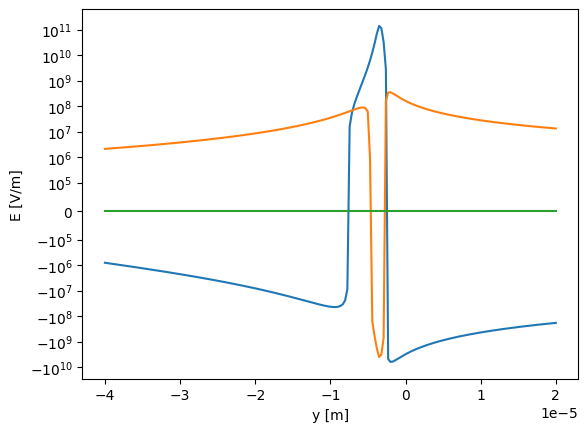

In [48]:
y_range = np.linspace(-4.0e-5, 2.0e-5,200)
P = np.stack([np.ones_like(y_range)*0.0002, y_range, np.zeros_like(y_range)]).transpose()
E_plot = np.apply_along_axis(E_lw, axis=1, arr=P)

fig, ax = plt.subplots()
ax.plot(y_range, E_plot)
ax.set_yscale('symlog', linthresh=1e5, linscale=1.0, base=10)
# plt.semilogy()
plt.xlabel('y [m]')
plt.ylabel('E [V/m]')
plt.show()

0.9999183966932949 78.27804734295493
E_grid: (500, 200, 3)
Ex: (500, 200)


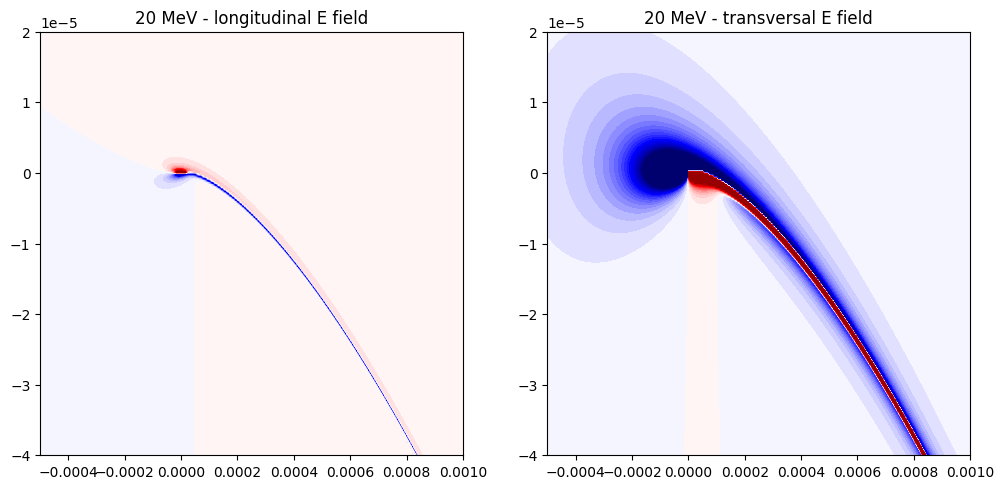

In [26]:
γ = 40.0e6 / mec2
β = sqrt(1.0-1.0/γ**2)
print(β, γ)

E_grid = np.apply_along_axis(E_lw, axis=2, arr=grid_3D)
print(f'E_grid: {E_grid.shape}')
Ex = E_grid[:,:,0]
Ey = E_grid[:,:,1]
print(f'Ex: {Ex.shape}')

elevels = np.linspace(-1.0e10, 1.0e10, num=51)*1.1
E_trans = np.clip(Ex, -1.0e10, 1.0e10)
E_long = np.clip(Ey, -1.0e10, 1.0e10)

fig, (ax1, ax2) = plt.subplots(nrows=1,ncols=2,figsize=(12,5.5))
ax1.contourf(x_grid.transpose(),y_grid.transpose(),E_long,elevels,cmap='seismic')
ax1.set_title("20 MeV - longitudinal E field")
ax2.contourf(x_grid.transpose(),y_grid.transpose(),E_trans,elevels,cmap='seismic')
ax2.set_title("20 MeV - transversal E field")
plt.show()

0.999947774650877 97.84755917869367
E_grid: (500, 200, 3)
Ex: (500, 200)


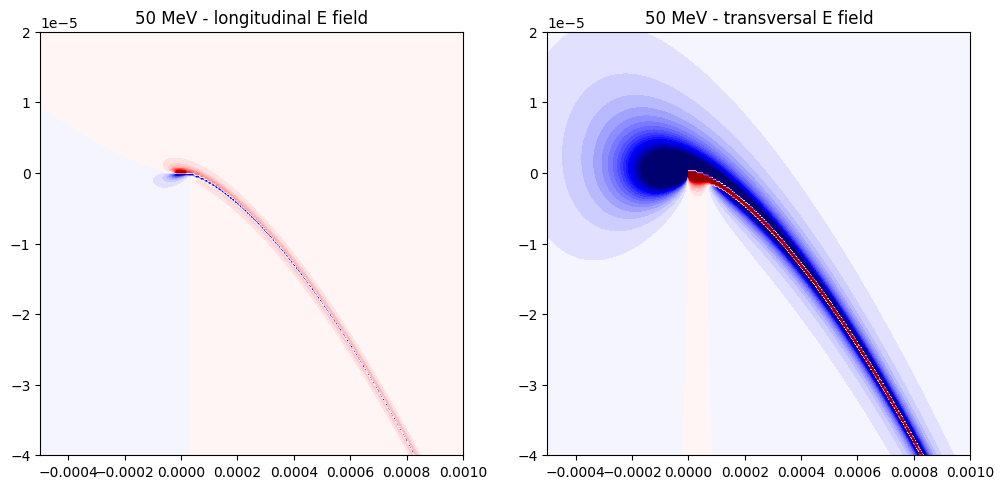

In [45]:
γ = 50.0e6 / mec2
β = sqrt(1.0-1.0/γ**2)
print(β, γ)

E_grid = np.apply_along_axis(E_lw, axis=2, arr=grid_3D)
print(f'E_grid: {E_grid.shape}')
Ex = E_grid[:,:,0]
Ey = E_grid[:,:,1]
print(f'Ex: {Ex.shape}')

elevels = np.linspace(-1.0e10, 1.0e10, num=51)*1.1
E_trans = np.clip(Ex, -1.0e10, 1.0e10)
E_long = np.clip(Ey, -1.0e10, 1.0e10)

fig, (ax1, ax2) = plt.subplots(nrows=1,ncols=2,figsize=(12,5.5))
ax1.contourf(x_grid.transpose(),y_grid.transpose(),E_long,elevels,cmap='seismic')
ax1.set_title("50 MeV - longitudinal E field")
ax2.contourf(x_grid.transpose(),y_grid.transpose(),E_trans,elevels,cmap='seismic')
ax2.set_title("50 MeV - transversal E field")
plt.show()

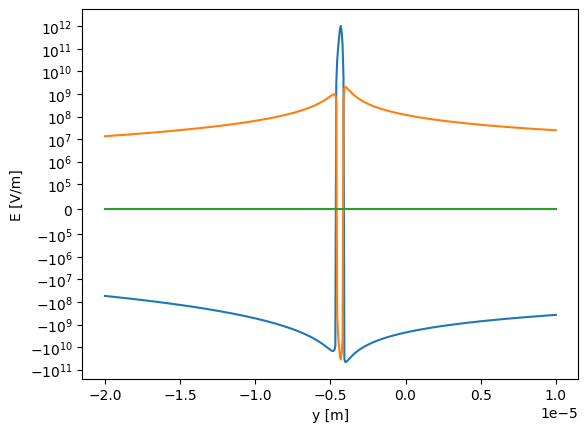

In [46]:
y_range = np.linspace(-2.0e-5, 1.0e-5, 500)
P = np.stack([np.ones_like(y_range)*0.0002, y_range, np.zeros_like(y_range)]).transpose()
E_plot = np.apply_along_axis(E_lw, axis=1, arr=P)

fig, ax = plt.subplots()
ax.plot(y_range, E_plot)
ax.set_yscale('symlog', linthresh=1e5, linscale=1.0, base=10)
# plt.semilogy()
plt.xlabel('y [m]')
plt.ylabel('E [V/m]')
plt.show()